In [1]:
import torch
import torch.nn as nn
import numpy as np
import einops
import matplotlib.pyplot as plt

In [2]:
def count_params(module, trainable_only=False, verbose=True):
    """
    Count parameters in a PyTorch module and format in M or B.

    Args:
        module: nn.Module
        trainable_only: if True, count only parameters with requires_grad=True

    Returns:
        (raw_count, formatted_string)
    """
    if trainable_only:
        n_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
    else:
        n_params = sum(p.numel() for p in module.parameters())

    # Format nicely
    if n_params >= 1e9:
        formatted = f"{n_params / 1e9:.2f}B"
    elif n_params >= 1e6:
        formatted = f"{n_params / 1e6:.2f}M"
    elif n_params >= 1e3:
        formatted = f"{n_params / 1e3:.2f}K"
    else:
        formatted = str(n_params)

    if verbose:
        print(f"Number of params in {module.__class__.__name__}: {formatted}")
    else:
        return n_params, formatted


class Linear(nn.Module):
    def __init__(self, in_features, out_features, device=None, dtype=None):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.device = device
        self.dtype = dtype

        # Define W matrix (with careful initialization)
        sigma = np.sqrt(2 / (out_features + in_features))
        data = nn.init.trunc_normal_(
            torch.empty(out_features, in_features, dtype=dtype, device=device), mean=0.0, std=sigma, a=-3 * sigma, b=3 * sigma,
        )
        self.W = nn.Parameter(data, requires_grad=True)

    def forward(self, x):
        """
        x: [..., d_in]
        y: [..., d_out]
        """
        return einops.einsum(x, self.W, "... d_in, d_out d_in -> ... d_out")


# Test linear module
device = 'cuda'
linear = Linear(64, 128, dtype=torch.bfloat16)
count_params(linear)

x = torch.randn((4, 16, 64), dtype=torch.bfloat16)
y = linear(x)
print(x.shape, y.shape)

Number of params in Linear: 8.19K
torch.Size([4, 16, 64]) torch.Size([4, 16, 128])


In [3]:

dtype = torch.float32
# dtype = torch.float16
# dtype = torch.bfloat16
device = 'cuda'

linear = Linear(64, 128, dtype=dtype, device=device)
count_params(linear)

x = torch.randn((4, 16, 64), dtype=dtype).to(device)
%timeit y = linear(x)

Number of params in Linear: 8.19K
54.5 μs ± 417 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [42]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, device=None, dtype=None):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.device = device
        self.dtype = dtype

        # Initialize embedding matrix
        data = nn.init.trunc_normal_(
            torch.empty(num_embeddings, embedding_dim, dtype=dtype, device=device), mean=0.0, std=1., a=-3, b=3,
        )
        self.E = nn.Parameter(data, requires_grad=True)

    def forward(self, token_ids):

        # # Basic sanity checks
        # assert token_ids.max() < self.num_embeddings
        # assert token_ids.min() > -1

        # Pick out the given indices
        x = self.E[token_ids]
        return x


embedding = Embedding(1257, 128)
count_params(embedding)

token_ids = torch.randint(0, 1257, (16, 64))
x = embedding(token_ids)

print(token_ids.shape, x.shape)

Number of params in Embedding: 160.90K
torch.Size([16, 64]) torch.Size([16, 64, 128])


In [43]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5, device=None, dtype=None):
        super().__init__()

        self.d_model = d_model
        self.eps = eps
        self.device = device
        self.dtype = dtype

        # Initialise parameters g
        self.g = nn.Parameter(torch.ones(d_model, device=device, dtype=dtype))

    def forward(self, x):
        in_dtype = x.dtype
        x = x.to(torch.float32)

        rms = (((x ** 2).mean(dim=-1) + self.eps) ** -0.5)
        rms = einops.repeat(rms, "b t -> b t d", d=self.d_model)
        result = rms * x * self.g 

        return result.to(in_dtype)


rms_norm = RMSNorm(128)
count_params(rms_norm)

x = torch.randn((2, 4, 128))
y = rms_norm(x)

x.mean(), x.std(), y.mean(), y.std()

Number of params in RMSNorm: 128


(tensor(0.0078),
 tensor(0.9926),
 tensor(0.0061, grad_fn=<MeanBackward0>),
 tensor(1.0005, grad_fn=<StdBackward0>))

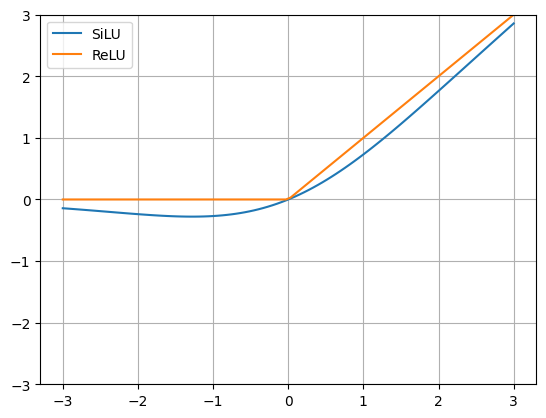

In [44]:
def silu(x):
    return x * torch.sigmoid(x)


def relu(x):
    return torch.threshold(x, 0, 0)


x = torch.linspace(-3, 3, 100)

fig, ax = plt.subplots(1, 1)
ax.plot(x, silu(x), label='SiLU')
ax.plot(x, relu(x), label="ReLU")
ax.set_ylim(-3, 3)
ax.grid(alpha=1)
ax.legend()
plt.show()

In [45]:
class FFNSwiGLU(nn.Module):
    def __init__(self, d_model, d_ff=None, device=None, dtype=None):
        super().__init__()

        self.d_model = d_model
        if d_ff is None:
            # Default value
            d_ff = int(8 * d_model / 3)
        self.d_ff = d_ff
        self.device = device
        self.dtype = dtype

        # Initialize parameters
        self.W1 = Linear(d_model, d_ff, device, dtype)
        self.W3 = Linear(d_model, d_ff, device, dtype)
        self.W2 = Linear(d_ff, d_model, device, dtype)

    def forward(self, x):
        return self.W2(silu(self.W1(x)) * (self.W3(x)))


class FFNSiLU(nn.Module):
    def __init__(self, d_model, d_ff=None, device=None, dtype=None):
        super().__init__()

        self.d_model = d_model
        if d_ff is None:
            # Default value
            d_ff = int(8 * d_model / 3)
        self.d_ff = d_ff
        self.device = device
        self.dtype = dtype

        # Initialize parameters
        self.W1 = Linear(d_model, d_ff, device, dtype)
        self.W2 = Linear(d_ff, d_model, device, dtype)

    def forward(self, x):
        return self.W2(silu(self.W1(x)))


ffn = FFNSwiGLU(128)
# ffn = FFNSiLU(128)
count_params(ffn)

x = torch.randn((4, 16, 128))
y = ffn(x)

print(x.shape, y.shape)

Number of params in FFNSwiGLU: 130.94K
torch.Size([4, 16, 128]) torch.Size([4, 16, 128])


In [46]:
y.std(), x.std()

(tensor(0.3630, grad_fn=<StdBackward0>), tensor(1.0029))

In [47]:
x = torch.randn(4)
y = torch.randn(3)
print(x, y)
einops.einsum(x, y, "a, b -> a b")

tensor([-0.7477, -0.7878,  0.3887, -0.5027]) tensor([-0.0526,  1.0976,  0.2022])


tensor([[ 0.0393, -0.8207, -0.1512],
        [ 0.0414, -0.8647, -0.1593],
        [-0.0204,  0.4267,  0.0786],
        [ 0.0264, -0.5517, -0.1016]])

In [48]:
def rope_angles(theta, d_k, max_seq_len):
    a = torch.arange(max_seq_len)
    b = 1. / (theta ** ((2 * torch.arange(d_k // 2) - 2) / d_k))
    return einops.einsum(a, b, "a, b -> a b")


class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, theta: float, d_k: int, max_seq_len: int, device=None):
        super().__init__()
        self.theta = theta
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.device = device

        # Register angle values to be used later
        angles = rope_angles(theta, d_k, max_seq_len)
        sin = torch.sin(angles)
        cos = torch.cos(angles)
        # [T d/2 2 2]: [i, k] is 2x2 rotation matrix
        values = einops.rearrange(
            torch.stack([cos, -sin, sin, cos], dim=-1),
            "t d_half (a b) -> t d_half a b", a=2, b=2,
        )
        self.register_buffer("values", values, persistent=False)

    def forward(self, x: torch.Tensor, token_positions: torch.Tensor) -> torch.Tensor:
        assert x.shape[:-1] == token_positions.shape

        # [... T d] -> [... T d/2 2]
        x_ = einops.rearrange(x, "... t (b c) -> ... t b c", b=self.d_k//2, c=2)

        # Take slice of the position embedding matrix according to token_positions
        rot = self.values[token_positions]

        # [... T d/2 2 2] x [... T d/2 2] -> [... T d/2 2]
        x_rot = einops.einsum(rot, x_, "... t d_half a_out a_in, ... t d_half a_in -> ... t d_half a_out")
        
        # [... T d/2 2] -> [... T d]
        x_rot = einops.rearrange(x_rot, "... t d_half a_out -> ... t (d_half a_out)")

        return x_rot


bs, seq_len, d_k, max_seq_len, n_heads = 4, 16, 128, 2048, 8
rope = RotaryPositionalEmbedding(theta=10e4, d_k=d_k, max_seq_len=max_seq_len)
count_params(rope)

# Test

x = torch.randn((bs, n_heads, seq_len, d_k))
token_positions = torch.randint(0, 2048, (bs, n_heads, seq_len))
print(x.shape, token_positions.shape)
y = rope(x, token_positions)

x.shape, y.shape

Number of params in RotaryPositionalEmbedding: 0
torch.Size([4, 8, 16, 128]) torch.Size([4, 8, 16])


(torch.Size([4, 8, 16, 128]), torch.Size([4, 8, 16, 128]))

In [49]:
y.mean(), y.std()

(tensor(0.0037), tensor(0.9987))

In [50]:
def softmax(x, dim):
    """Applies softmax to x along dim dimension."""
    z = torch.exp(x - x.max(dim=dim, keepdim=True).values)
    return z / z.sum(dim=dim, keepdim=True)


x = torch.randn((3, 4))
print(x)
y = softmax(x, 1)
print(y)
y = softmax(x, 0)
print(y)

x = torch.randn((4, 16, 32, 2048))
y = softmax(x, dim=-1)
print(x.shape, y.shape)

tensor([[-0.9277, -0.0270, -0.0907, -0.1163],
        [-1.0508,  1.3355, -0.3011,  1.1156],
        [-1.1804,  0.0381,  0.8458, -0.3918]])
tensor([[0.1247, 0.3068, 0.2879, 0.2806],
        [0.0440, 0.4787, 0.0932, 0.3842],
        [0.0706, 0.2387, 0.5354, 0.1553]])
tensor([[0.3758, 0.1674, 0.2293, 0.1928],
        [0.3323, 0.6539, 0.1858, 0.6608],
        [0.2919, 0.1787, 0.5849, 0.1464]])
torch.Size([4, 16, 32, 2048]) torch.Size([4, 16, 32, 2048])


In [51]:
def scaled_dot_product_attention(q, k, v, mask):
    """
    Args:
        q (torch.Tensor): [batch_size, ..., seq_len, d_k]
        k (torch.Tensor): [batch_size, ..., seq_len, d_k]
        v (torch.Tensor): [batch_size, ..., seq_len, d_v]
        mask (torch.Tensor): apply attention to only entries where mask=True
    """
    d_k = q.shape[-1]

    x = einops.einsum(q, k, "b ... t_q d_k, b ... t_k d_k -> b ... t_q t_k") * (np.sqrt(d_k) ** -0.5)

    # Apply mask
    x = x.masked_fill(~mask, float('-inf'))

    # Softmax
    x = softmax(x, dim=-1)
    # print(x[0, 0, 0])
    # print(mask[0])
    
    x = einops.einsum(x, v, "b ... t_q t_k, b ... t_k d_v -> b ... t_q d_v")
    return x


q = torch.randn((4, 8, 16, 128))
k = torch.randn((4, 8, 16, 128))
v = torch.randn((4, 8, 16, 256))
mask = torch.randint(0, 2, (16, 16)).to(torch.bool)
s = scaled_dot_product_attention(q, k, v, mask)
s.shape

torch.Size([4, 8, 16, 256])

In [52]:
class CausalMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, max_seq_len):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads

        # Calculate d_k and d_v
        d_k = d_model // num_heads
        self.d_k = d_k
        d_v = d_model // num_heads
        self.d_v = d_v

        # Projections
        self.WQ = Linear(d_model, num_heads * d_k)
        self.WK = Linear(d_model, num_heads * d_k)
        self.WV = Linear(d_model, num_heads * d_v)
        self.WO = Linear(num_heads * d_v, d_model)

        # Define rope position embeddings
        self.rope = RotaryPositionalEmbedding(theta=1e4, max_seq_len=max_seq_len, d_k=d_k)

    def forward(self, x, token_positions):
        # x: [B, seq_len, d_model]
        batch_size, seq_len, d_model = x.shape

        # Project: [B, seq_len, d_model] -> [B, seq_len, num_heads x d_*]
        q, k, v = self.WQ(x), self.WK(x), self.WV(x)
        q = einops.rearrange(q, "b t (h d) -> b h t d", h=self.num_heads, d=self.d_k)
        k = einops.rearrange(k, "b t (h d) -> b h t d", h=self.num_heads, d=self.d_k)
        v = einops.rearrange(v, "b t (h d) -> b h t d", h=self.num_heads, d=self.d_v)

        # Repeat the token positions along heads dimension
        token_positions = einops.repeat(token_positions, "b t -> b h t", h=self.num_heads)

        # Apply RoPE
        q = self.rope(q, token_positions)
        k = self.rope(k, token_positions)

        # Construct causal mask
        mask = torch.triu(torch.ones((seq_len, seq_len))).T.to(dtype=torch.bool, device=x.device)

        # Apply MHSA
        x = scaled_dot_product_attention(q, k, v, mask)

        # Output projection
        x = einops.rearrange(x, "b h t d_v -> b t (h d_v)")
        x = self.WO(x)

        return x


# Test
bs, seq_len, d_model = 4, 16, 128
x = torch.randn((bs, seq_len, d_model))
token_positions = torch.randint(0, 2048, (bs, seq_len))

cmhsa = CausalMultiHeadSelfAttention(d_model, 8, 2048)
count_params(cmhsa)

y = cmhsa(x, token_positions)
print(x.shape, y.shape)

Number of params in CausalMultiHeadSelfAttention: 65.54K
torch.Size([4, 16, 128]) torch.Size([4, 16, 128])


In [56]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, max_seq_len):
        super().__init__()

        self.cmhsa = CausalMultiHeadSelfAttention(d_model, num_heads, max_seq_len)
        self.ffn = FFNSwiGLU(d_model, d_ff)
        self.rmsnorm1 = RMSNorm(d_model)
        self.rmsnorm2 = RMSNorm(d_model)

    def forward(self, x, token_positions):
        x = x + self.cmhsa(self.rmsnorm1(x), token_positions)
        x = x + self.ffn(self.rmsnorm2(x))
        return x

d_model = 384
d_ff = 384 * 8 // 3
num_heads = 8
max_seq_len = 2048
block = TransformerBlock(d_model, d_ff, num_heads, max_seq_len)
count_params(block)

x = torch.randn((bs, seq_len, d_model))
token_positions = torch.randint(0, max_seq_len, (bs, seq_len))
y = block(x, token_positions)
print(x.shape, y.shape)

Number of params in TransformerBlock: 1.77M
torch.Size([4, 16, 384]) torch.Size([4, 16, 384])


In [66]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, context_length, num_layers, d_model, d_ff, num_heads, max_seq_len):
        super().__init__()

        self.vocab_size = vocab_size
        self.context_length = context_length
        self.num_layers = num_layers
        self.d_model = d_model
        self.d_ff = d_ff
        self.num_heads = num_heads
        self.max_seq_len = max_seq_len

        # Embedding
        self.embedding = Embedding(vocab_size, d_model)

        # Layers
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, d_ff, num_heads, max_seq_len) for _ in range(num_layers)]
        )

        # RMSNorm at the output
        self.rmsnorm_output = RMSNorm(d_model)

        # Linear layer
        self.lm_head = Linear(d_model, vocab_size)
        
    def forward(self, token_ids, token_positions):
        x = self.embedding(token_ids)
        for b in self.blocks:
            x = b(x, token_positions)
        x = self.rmsnorm_output(x)
        x = self.lm_head(x)
        x = softmax(x, dim=-1)
        return x


d_model = 384
d_ff = 384 * 8 // 3
num_heads = 8
max_seq_len = 2048
vocab_size = 10257
context_length = 1024
num_layers = 12

model = Transformer(vocab_size, context_length, num_layers, d_model, d_ff, num_heads, max_seq_len)
count_params(model)

token_ids = torch.randint(0, vocab_size, (bs, context_length))
token_positions = torch.randint(0, max_seq_len, (bs, context_length))
y = model(token_ids, token_positions)
print(token_ids.shape, y.shape)

Number of params in Transformer: 29.12M
torch.Size([4, 1024]) torch.Size([4, 1024, 10257])


In [ ]:
y[0, -1].sum(), y[0, -1].std(), y[0, -1].mean()

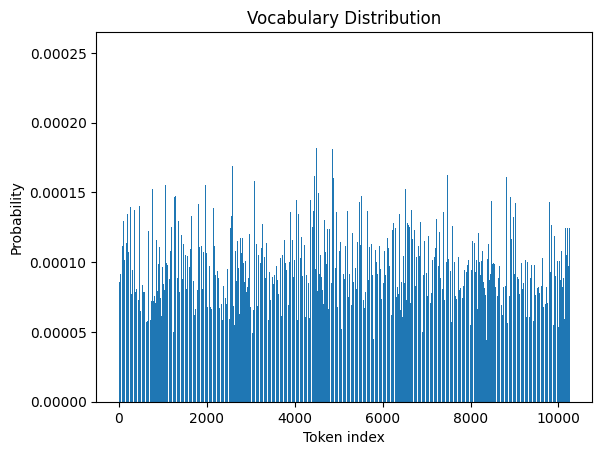

In [76]:
probs = y[0, -1].detach()

plt.figure()
plt.bar(range(len(probs)), probs)
plt.xlabel("Token index")
plt.ylabel("Probability")
plt.title("Vocabulary Distribution")
plt.show()

### Old code

In [83]:
def rope_angles(theta, d_k, max_seq_len):
    a = torch.arange(max_seq_len)
    b = 1. / (theta ** ((2 * torch.arange(d_k // 2) - 2) / d_k))
    return einops.einsum(a, b, "a, b -> a b")

theta, d_k, max_seq_len = 1e4, 128, 512
angles = rope_angles(theta, d_k, max_seq_len)
angles.shape

torch.Size([512, 64])

In [107]:
# Test
i = np.random.randint(0, max_seq_len)
k = np.random.randint(0, d_k // 2)
angle_ik = i / (theta ** ((2*k - 2) / d_k))
assert np.isclose(angle_ik, angles[i, k].item())

In [108]:
sin = torch.sin(angles)
cos = torch.cos(angles)

sin.shape, cos.shape

(torch.Size([512, 64]), torch.Size([512, 64]))

In [129]:
values = einops.rearrange(
    torch.stack([cos, -sin, sin, cos], dim=-1), "t d_half (a b) -> t d_half a b", a=2, b=2,
)

# Sanity check
i = np.random.randint(0, max_seq_len)
k = np.random.randint(0, d_k // 2)
angle_ik = i / (theta ** ((2*k - 2) / d_k))
value_ik = torch.tensor(
    [
        [np.cos(angle_ik), -np.sin(angle_ik)],
        [np.sin(angle_ik), np.cos(angle_ik)],
    ]
)
torch.allclose(value_ik.float(), values[i, k].float())

True

In [130]:
value_ik.float(), values[i, k].float()

(tensor([[ 0.9996, -0.0274],
         [ 0.0274,  0.9996]]),
 tensor([[ 0.9996, -0.0274],
         [ 0.0274,  0.9996]]))

In [138]:
values.shape

torch.Size([512, 64, 2, 2])

In [137]:
x = torch.randn((4, 16, 128))
print(x[0, 0, :10])
x = einops.rearrange(x, "... t (b c) -> ... t b c", c=2, b=d_k//2)
print(x[0, 0, :5])
x.shape

tensor([ 0.5314, -0.0377,  0.4294,  1.4478,  0.3860, -0.0562, -0.4743, -0.1025,
        -0.5763, -0.1335])
tensor([[ 0.5314, -0.0377],
        [ 0.4294,  1.4478],
        [ 0.3860, -0.0562],
        [-0.4743, -0.1025],
        [-0.5763, -0.1335]])


torch.Size([4, 16, 64, 2])

In [183]:
values.shape

torch.Size([512, 64, 2, 2])

In [187]:
x = torch.randn((4, 16, 128))
token_positions = torch.randint(0, 512, (4, 16))
values[token_positions].shape

torch.Size([4, 16, 64, 2, 2])

In [190]:
values[token_positions[0]].shape

torch.Size([16, 64, 2, 2])

In [139]:
t = x.shape[1]
values[:t].shape

torch.Size([16, 64, 2, 2])

In [150]:
x[0, 0].shape

torch.Size([64, 2])

In [154]:
torch.bmm(values[0], x[0, 0][:, :, None])[:, :, 0].shape

torch.Size([64, 2])

In [182]:
t = x.shape[1]

# [T d/2 2 2] x [... T d/2 2] -> [... T d/2 2]
x_rot = einops.einsum(values[:t], x, "t d_half a_out a_in, ... t d_half a_in -> ... t d_half a_out")

# Sanity check (on first sequence in the batch)
i = np.random.randint(0, t)
# i = 1
assert torch.allclose(torch.bmm(values[i], x[0, i][:, :, None])[:, :, 0], x_rot[0, i])
x_rot.shape

# [... T d/2 2] -> [... T d]
x_rot = einops.rearrange(x_rot, "... t d_half a_out -> ... t (d_half a_out)")
x_rot.shape, x.shape

(torch.Size([4, 16, 128]), torch.Size([4, 16, 64, 2]))

In [164]:
x.shape

torch.Size([4, 16, 64, 2])